# Pneumonia Chest X-ray Classification using Deep Learning

## Project Overview

This project aims to develop a robust deep learning system capable of automatically detecting Pneumonia from chest X-ray images. Multiple transfer learning architectures are explored and compared to identify the best-performing model.

## Objectives

- Perform detailed Exploratory Data Analysis (EDA)
- Apply image preprocessing and augmentation
- Train multiple deep learning models
- Compare model performance using multiple evaluation metrics
- Generate explainable predictions using Grad-CAM
- Deploy the best model using Streamlit

---

In [1]:
import os
import random
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score
)

from tqdm import tqdm
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow Version :", tf.__version__)
print("NumPy Version      :", np.__version__)
print("GPU Available      :", tf.config.list_physical_devices('GPU'))

TensorFlow Version : 2.21.0
NumPy Version      : 2.2.6
GPU Available      : []


In [2]:
BASE_DIR = "../data/chest_xray"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "val")
TEST_DIR = os.path.join(BASE_DIR, "test")

print("Train Path :", TRAIN_DIR)
print("Validation Path :", VAL_DIR)
print("Test Path :", TEST_DIR)

for folder in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    print("\n", folder)
    print(os.listdir(folder))

Train Path : ../data/chest_xray\train
Validation Path : ../data/chest_xray\val
Test Path : ../data/chest_xray\test

 ../data/chest_xray\train
['.DS_Store', 'NORMAL', 'PNEUMONIA']

 ../data/chest_xray\val
['.DS_Store', 'NORMAL', 'PNEUMONIA']

 ../data/chest_xray\test
['.DS_Store', 'NORMAL', 'PNEUMONIA']


# Exploratory Data Analysis

This section explores the dataset by creating a structured dataframe, analyzing class distribution, and examining image properties before training any deep learning model.

In [3]:
train_images = []
val_images = []
test_images = []

for dataset, folder in [("Train", TRAIN_DIR), ("Validation", VAL_DIR), ("Test", TEST_DIR)]:
    for label in sorted(os.listdir(folder)):
        label_path = os.path.join(folder, label)

        if not os.path.isdir(label_path):
            continue

        for image in sorted(os.listdir(label_path)):
            image_path = os.path.join(label_path, image)

            if not os.path.isfile(image_path):
                continue

            if image.lower().endswith((".jpg", ".jpeg", ".png")):
                row = [dataset, label, image_path]

                if dataset == "Train":
                    train_images.append(row)
                elif dataset == "Validation":
                    val_images.append(row)
                else:
                    test_images.append(row)

df = pd.DataFrame(
    train_images + val_images + test_images,
    columns=["Dataset", "Label", "Path"]
)

df.head()

,Dataset,Label,Path
0,Train,NORMAL,../data/chest_xray\train\NORMAL\IM-0115-0001.jpeg
1,Train,NORMAL,../data/chest_xray\train\NORMAL\IM-0117-0001.jpeg
2,Train,NORMAL,../data/chest_xray\train\NORMAL\IM-0119-0001.jpeg
3,Train,NORMAL,../data/chest_xray\train\NORMAL\IM-0122-0001.jpeg
4,Train,NORMAL,../data/chest_xray\train\NORMAL\IM-0125-0001.jpeg


In [4]:
display(df.sample(10))

print(f"Total Images      : {len(df)}")
print(f"Training Images   : {len(train_images)}")
print(f"Validation Images : {len(val_images)}")
print(f"Testing Images    : {len(test_images)}")

print("\nDataset Distribution")

display(
    df.groupby(["Dataset", "Label"])
      .size()
      .reset_index(name="Count")
)

,Dataset,Label,Path
3649,Train,PNEUMONIA,../data/chest_xray\train\PNEUMONIA\person398_b...
4211,Train,PNEUMONIA,../data/chest_xray\train\PNEUMONIA\person539_v...
960,Train,NORMAL,../data/chest_xray\train\NORMAL\NORMAL2-IM-090...
23,Train,NORMAL,../data/chest_xray\train\NORMAL\IM-0160-0001.jpeg
810,Train,NORMAL,../data/chest_xray\train\NORMAL\NORMAL2-IM-066...
1670,Train,PNEUMONIA,../data/chest_xray\train\PNEUMONIA\person1176_...
1176,Train,NORMAL,../data/chest_xray\train\NORMAL\NORMAL2-IM-117...
2579,Train,PNEUMONIA,../data/chest_xray\train\PNEUMONIA\person1574_...
4333,Train,PNEUMONIA,../data/chest_xray\train\PNEUMONIA\person56_ba...
1897,Train,PNEUMONIA,../data/chest_xray\train\PNEUMONIA\person1288_...


Total Images      : 5856
Training Images   : 5216
Validation Images : 16
Testing Images    : 624

Dataset Distribution


,Dataset,Label,Count
0,Test,NORMAL,234
1,Test,PNEUMONIA,390
2,Train,NORMAL,1341
3,Train,PNEUMONIA,3875
4,Validation,NORMAL,8
5,Validation,PNEUMONIA,8


# Class Distribution Analysis

This section examines the balance between Normal and Pneumonia images across the dataset to identify any class imbalance before model training.

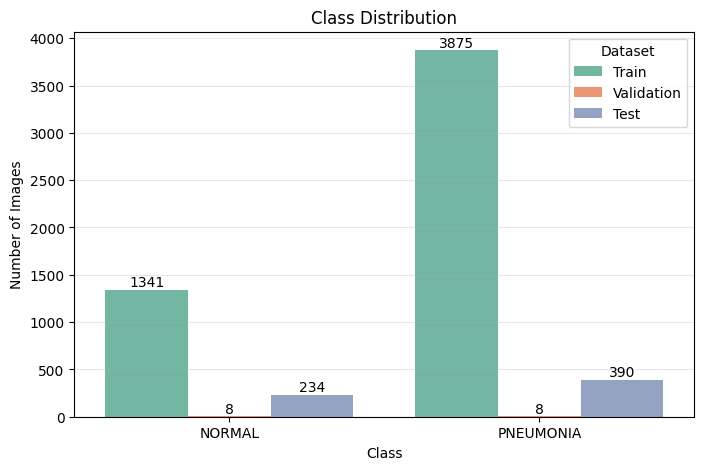

In [5]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Label",
    hue="Dataset",
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.grid(axis="y", alpha=0.3)

plt.show()

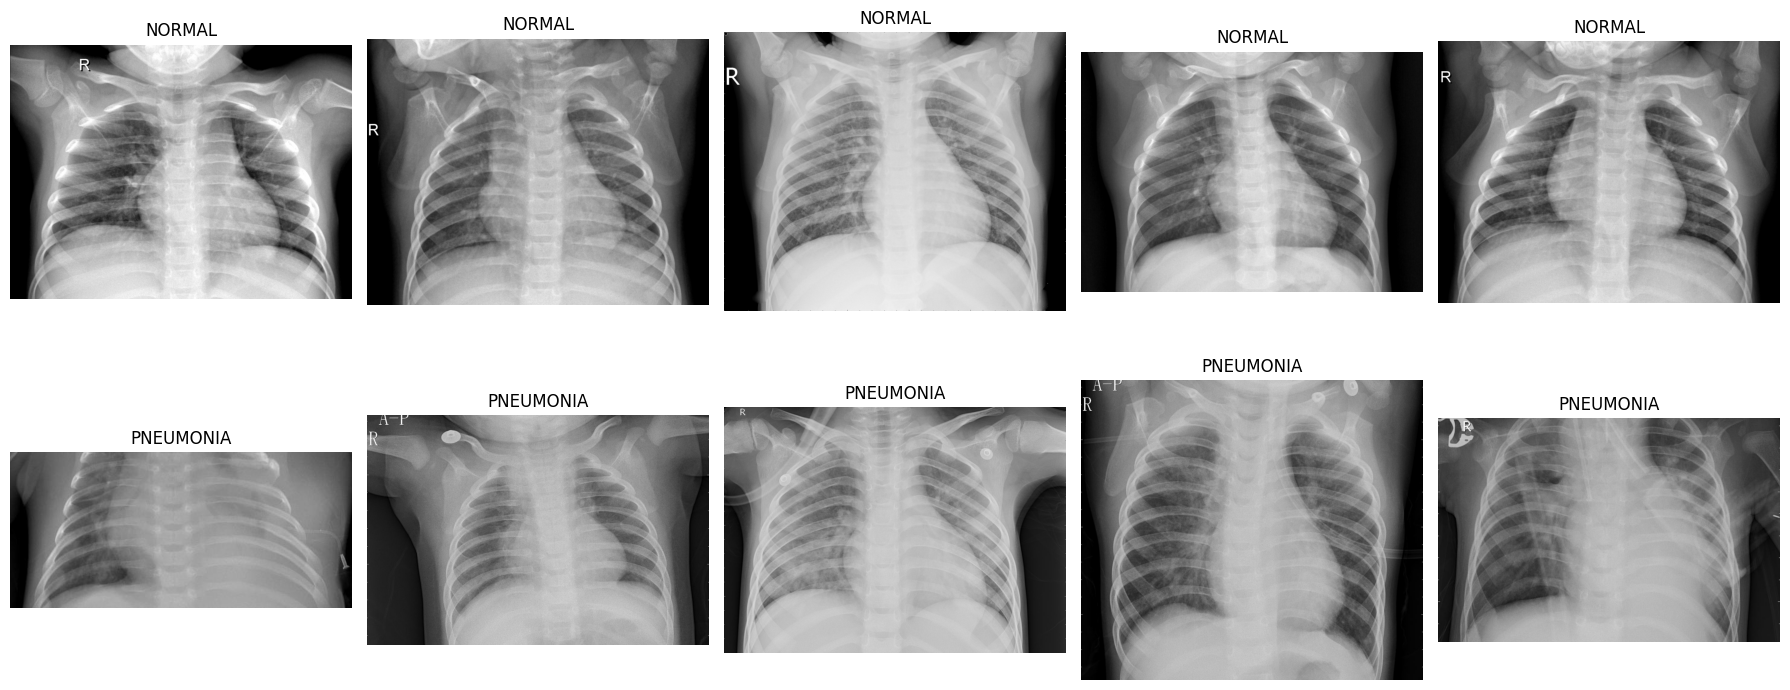

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

classes = sorted(df["Label"].unique())

for row, label in enumerate(classes):
    samples = df[df["Label"] == label].sample(5, random_state=42)

    for col, (_, sample) in enumerate(samples.iterrows()):
        image = cv2.imread(sample["Path"])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        axes[row, col].imshow(image)
        axes[row, col].set_title(label)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

# Image Metadata Extraction

Image properties such as dimensions, aspect ratio, file size, brightness, contrast, and pixel statistics are extracted for further analysis.

In [7]:
image_stats = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    image = cv2.imread(row["Path"], cv2.IMREAD_GRAYSCALE)

    height, width = image.shape

    image_stats.append({
        "Dataset": row["Dataset"],
        "Label": row["Label"],
        "Width": width,
        "Height": height,
        "Aspect_Ratio": round(width / height, 3),
        "File_Size_KB": round(os.path.getsize(row["Path"]) / 1024, 2),
        "Mean_Intensity": image.mean(),
        "Std_Intensity": image.std(),
        "Min_Pixel": image.min(),
        "Max_Pixel": image.max(),
        "Brightness": image.mean(),
        "Contrast": image.std()
    })

image_stats = pd.DataFrame(image_stats)

image_stats.head()

100%|██████████████████████████████████████████████████████████████████████████████| 5856/5856 [04:11<00:00, 23.27it/s]


,Dataset,Label,Width,Height,Aspect_Ratio,File_Size_KB,Mean_Intensity,Std_Intensity,Min_Pixel,Max_Pixel,Brightness,Contrast
0,Train,NORMAL,2090,1858,1.125,850.38,128.907478,62.301030,0,255,128.907478,62.301030
1,Train,NORMAL,1422,1152,1.234,396.78,100.650624,59.808347,0,255,100.650624,59.808347
2,Train,NORMAL,1810,1434,1.262,568.98,121.971530,68.856428,0,255,121.971530,68.856428
3,Train,NORMAL,1618,1279,1.265,460.50,132.986188,64.970663,0,255,132.986188,64.970663
4,Train,NORMAL,1600,1125,1.422,440.71,106.224797,65.088725,0,255,106.224797,65.088725


In [8]:
display(image_stats.describe().T)

print(f"Duplicate Rows : {image_stats.duplicated().sum()}")

print(f"\nMissing Values\n")

display(image_stats.isnull().sum())

,count,mean,std,min,25%,50%,75%,max
Width,5856.0,1327.880806,363.500922,384.000000,1056.000000,1281.000000,1560.000000,2916.000000
Height,5856.0,970.689037,383.392117,127.000000,688.000000,888.000000,1187.000000,2713.000000
Aspect_Ratio,5856.0,1.442986,0.254354,0.835000,1.261750,1.416000,1.586000,3.379000
File_Size_KB,5856.0,206.199255,258.600342,5.310000,54.750000,93.590000,230.487500,2357.760000
Mean_Intensity,5856.0,122.786271,18.391648,58.722966,111.616378,122.753346,134.313617,221.536623
Std_Intensity,5856.0,56.989903,9.396742,20.415354,50.736895,57.328348,63.696503,87.480423
Min_Pixel,5856.0,0.212090,2.775167,0.000000,0.000000,0.000000,0.000000,76.000000
Max_Pixel,5856.0,252.759563,10.627402,153.000000,255.000000,255.000000,255.000000,255.000000
Brightness,5856.0,122.786271,18.391648,58.722966,111.616378,122.753346,134.313617,221.536623
Contrast,5856.0,56.989903,9.396742,20.415354,50.736895,57.328348,63.696503,87.480423


Duplicate Rows : 32

Missing Values



Dataset           0
Label             0
Width             0
Height            0
Aspect_Ratio      0
File_Size_KB      0
Mean_Intensity    0
Std_Intensity     0
Min_Pixel         0
Max_Pixel         0
Brightness        0
Contrast          0
dtype: int64

# Distribution of Image Characteristics

The distributions of image dimensions, file sizes, brightness, and contrast are analyzed to understand dataset variability and identify preprocessing requirements.

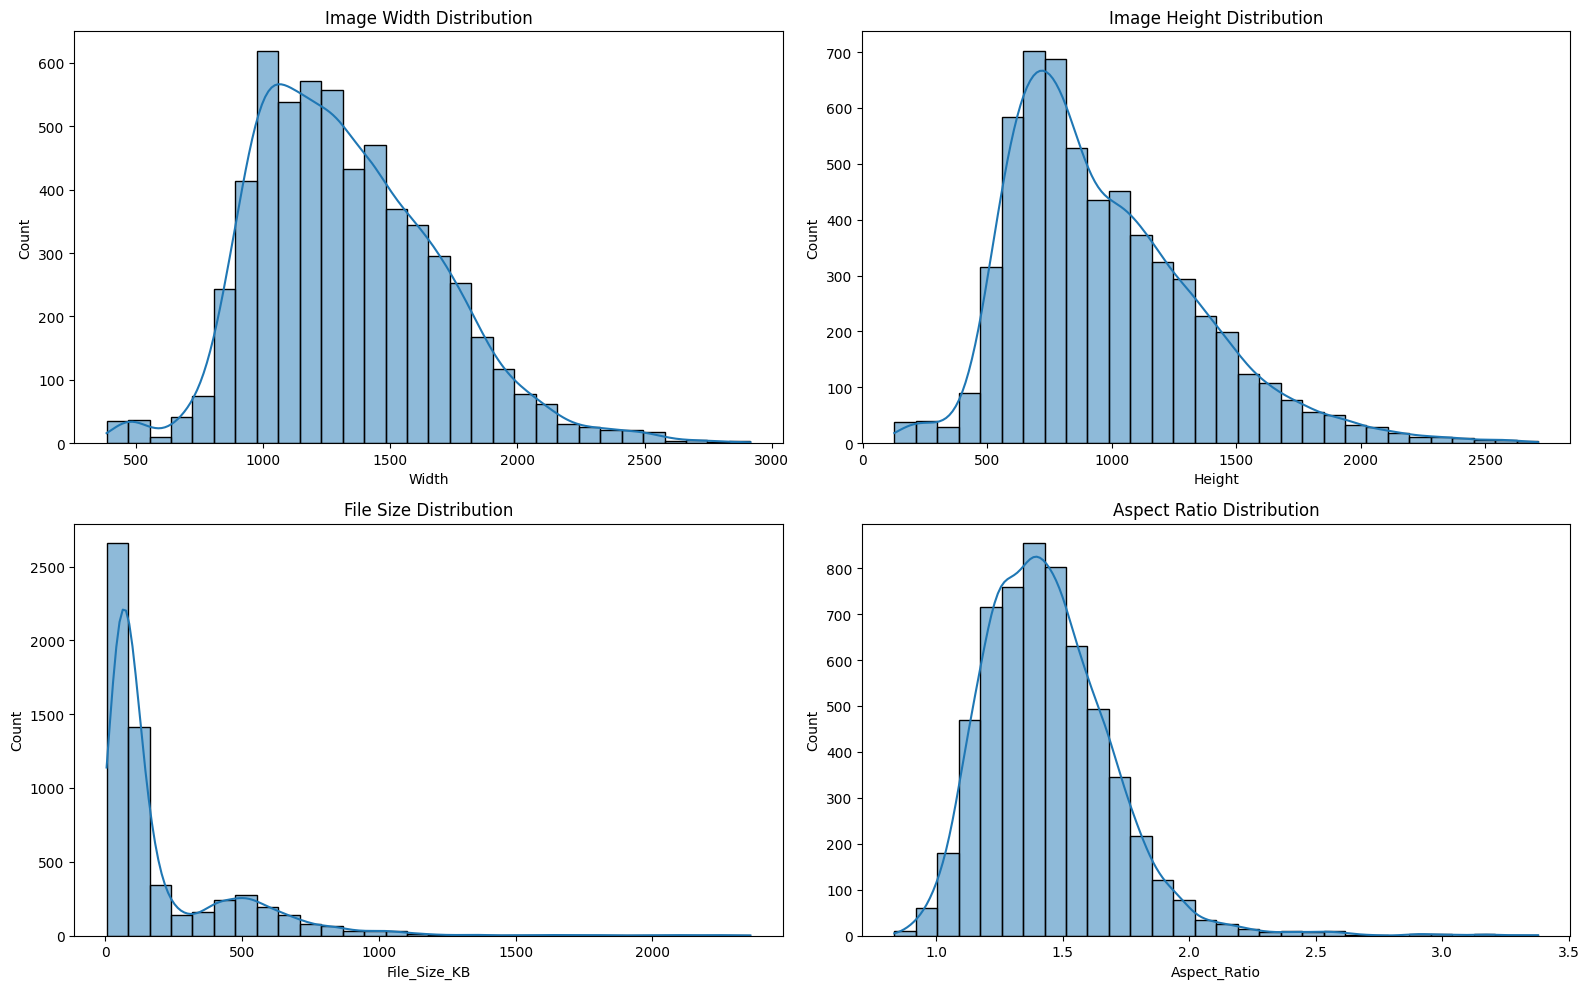

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(image_stats["Width"], bins=30, kde=True, ax=axes[0,0])
axes[0,0].set_title("Image Width Distribution")

sns.histplot(image_stats["Height"], bins=30, kde=True, ax=axes[0,1])
axes[0,1].set_title("Image Height Distribution")

sns.histplot(image_stats["File_Size_KB"], bins=30, kde=True, ax=axes[1,0])
axes[1,0].set_title("File Size Distribution")

sns.histplot(image_stats["Aspect_Ratio"], bins=30, kde=True, ax=axes[1,1])
axes[1,1].set_title("Aspect Ratio Distribution")

plt.tight_layout()
plt.show()

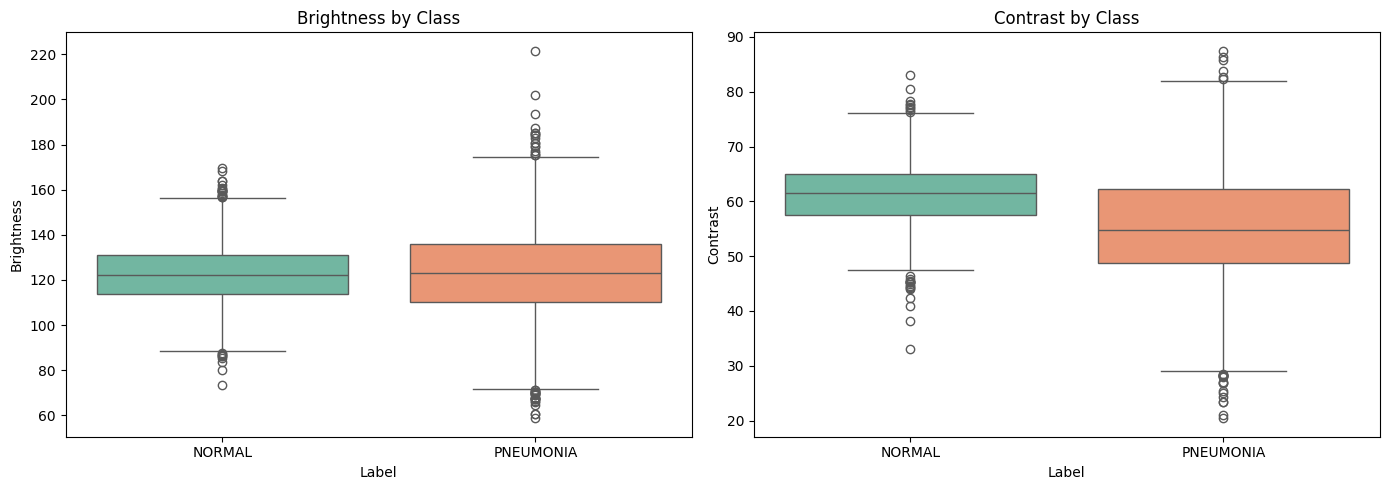

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(
    data=image_stats,
    x="Label",
    y="Brightness",
    palette="Set2",
    ax=axes[0]
)

axes[0].set_title("Brightness by Class")

sns.boxplot(
    data=image_stats,
    x="Label",
    y="Contrast",
    palette="Set2",
    ax=axes[1]
)

axes[1].set_title("Contrast by Class")

plt.tight_layout()
plt.show()

# Image Quality Analysis

Image quality is evaluated using blur detection and entropy analysis. Blur estimation helps identify low-quality images, while entropy measures the amount of information present in each image.

In [11]:
laplacian_variance = []
entropy_values = []

for path in tqdm(df["Path"]):
    image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    blur = cv2.Laplacian(image, cv2.CV_64F).var()

    hist = cv2.calcHist([image], [0], None, [256], [0, 256])
    hist = hist / hist.sum()

    entropy = -np.sum(hist * np.log2(hist + 1e-10))

    laplacian_variance.append(blur)
    entropy_values.append(entropy)

image_stats["Blur_Score"] = laplacian_variance
image_stats["Entropy"] = entropy_values

image_stats.head()

100%|██████████████████████████████████████████████████████████████████████████████| 5856/5856 [03:27<00:00, 28.25it/s]


,Dataset,Label,Width,Height,Aspect_Ratio,File_Size_KB,Mean_Intensity,Std_Intensity,Min_Pixel,Max_Pixel,Brightness,Contrast,Blur_Score,Entropy
0,Train,NORMAL,2090,1858,1.125,850.38,128.907478,62.301030,0,255,128.907478,62.301030,72.224400,7.676016
1,Train,NORMAL,1422,1152,1.234,396.78,100.650624,59.808347,0,255,100.650624,59.808347,97.994290,7.530555
2,Train,NORMAL,1810,1434,1.262,568.98,121.971530,68.856428,0,255,121.971530,68.856428,90.731133,7.303908
3,Train,NORMAL,1618,1279,1.265,460.50,132.986188,64.970663,0,255,132.986188,64.970663,80.234756,7.573775
4,Train,NORMAL,1600,1125,1.422,440.71,106.224797,65.088725,0,255,106.224797,65.088725,112.328822,7.331294


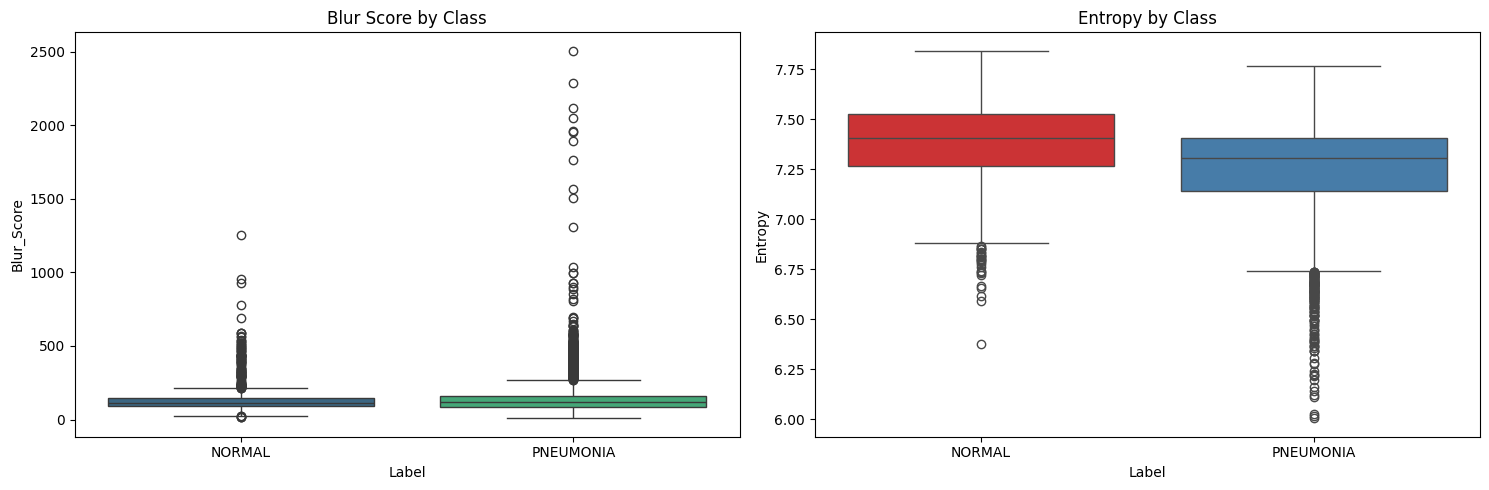

,count,mean,std,min,25%,50%,75%,max
Blur_Score,5856.0,143.627935,125.405722,8.124156,90.428048,118.131342,155.329269,2505.983038
Entropy,5856.0,7.285662,0.228024,6.004755,7.176886,7.328520,7.439839,7.841582


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))

sns.boxplot(
    data=image_stats,
    x="Label",
    y="Blur_Score",
    palette="viridis",
    ax=axes[0]
)

axes[0].set_title("Blur Score by Class")

sns.boxplot(
    data=image_stats,
    x="Label",
    y="Entropy",
    palette="Set1",
    ax=axes[1]
)

axes[1].set_title("Entropy by Class")

plt.tight_layout()
plt.show()

display(
    image_stats[["Blur_Score","Entropy"]].describe().T
)

In [13]:
import hashlib

hashes = []
corrupted = []

for path in tqdm(df["Path"]):
    try:
        with open(path, "rb") as f:
            hashes.append(hashlib.md5(f.read()).hexdigest())
        corrupted.append(False)
    except:
        hashes.append(None)
        corrupted.append(True)

image_stats["Hash"] = hashes
image_stats["Corrupted"] = corrupted

duplicate_images = image_stats["Hash"].duplicated().sum()

print(f"Corrupted Images : {image_stats['Corrupted'].sum()}")
print(f"Duplicate Images : {duplicate_images}")

100%|████████████████████████████████████████████████████████████████████████████| 5856/5856 [00:05<00:00, 1066.60it/s]

Corrupted Images : 0
Duplicate Images : 32


In [14]:
quality_report = pd.DataFrame({
    "Metric": [
        "Total Images",
        "Corrupted Images",
        "Duplicate Images",
        "Very Dark Images",
        "Very Bright Images",
        "Very Blurry Images"
    ],
    "Count": [
        len(image_stats),
        image_stats["Corrupted"].sum(),
        duplicate_images,
        (image_stats["Brightness"] < 60).sum(),
        (image_stats["Brightness"] > 190).sum(),
        (image_stats["Blur_Score"] < 100).sum()
    ]
})

display(quality_report)

,Metric,Count
0,Total Images,5856
1,Corrupted Images,0
2,Duplicate Images,32
3,Very Dark Images,1
4,Very Bright Images,3
5,Very Blurry Images,1935


# Image Preprocessing

The images are resized, enhanced using CLAHE, normalized, and converted into TensorFlow datasets for efficient model training.

In [15]:
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_df = df[df["Dataset"] == "Train"].reset_index(drop=True)
test_df = df[df["Dataset"] == "Test"].reset_index(drop=True)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["Label"],
    random_state=SEED
)

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(4172, 3)
(1044, 3)
(624, 3)


In [16]:
label_map = {
    "NORMAL": 0,
    "PNEUMONIA": 1
}

train_df["Target"] = train_df["Label"].map(label_map)
val_df["Target"] = val_df["Label"].map(label_map)
test_df["Target"] = test_df["Label"].map(label_map)

display(train_df.head())

print(label_map)

,Dataset,Label,Path,Target
99,Train,NORMAL,../data/chest_xray\train\NORMAL\IM-0273-0001.jpeg,0
1284,Train,NORMAL,../data/chest_xray\train\NORMAL\NORMAL2-IM-130...,0
5142,Train,PNEUMONIA,../data/chest_xray\train\PNEUMONIA\person963_v...,1
1365,Train,PNEUMONIA,../data/chest_xray\train\PNEUMONIA\person1016_...,1
2649,Train,PNEUMONIA,../data/chest_xray\train\PNEUMONIA\person1604_...,1


{'NORMAL': 0, 'PNEUMONIA': 1}


In [33]:
def load_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_jpeg(image, channels=3)

    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    return image, label

In [34]:
train_dataset = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            train_df["Path"].values,
            train_df["Target"].values.astype(np.int32)
        )
    )
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(len(train_df), seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_dataset = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            val_df["Path"].values,
            val_df["Target"].values.astype(np.int32)
        )
    )
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_dataset = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            test_df["Path"].values,
            test_df["Target"].values.astype(np.int32)
        )
    )
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

(32, 224, 224, 3)
(32,)


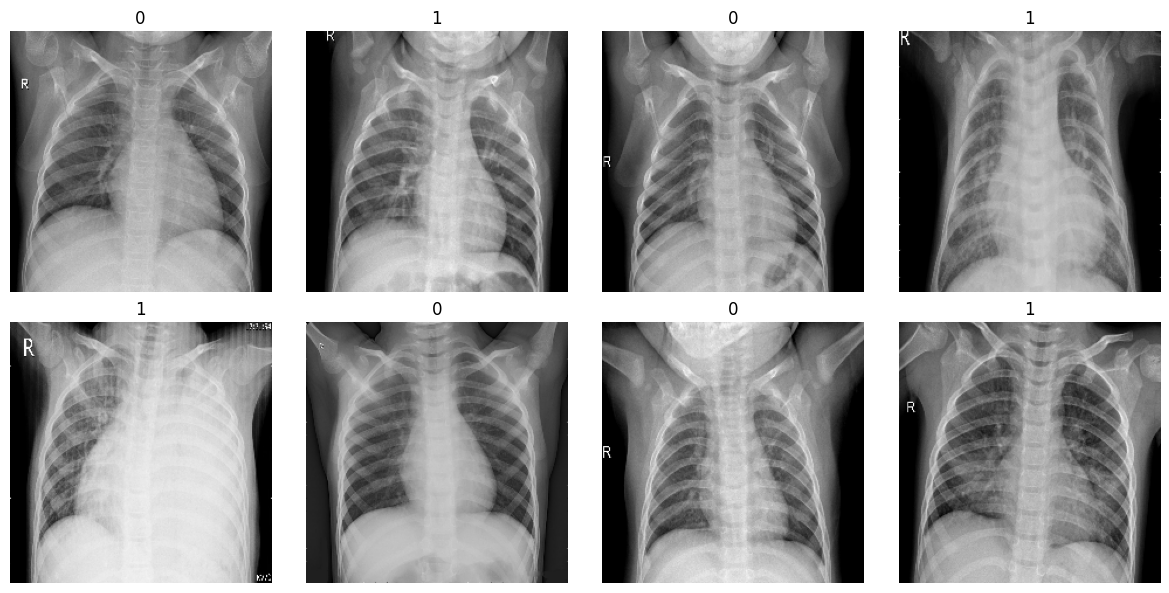

In [35]:
images, labels = next(iter(train_dataset))

print(images.shape)
print(labels.shape)

plt.figure(figsize=(12,6))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(tf.cast(images[i], tf.uint8))
    plt.title(labels[i].numpy())
    plt.axis("off")

plt.tight_layout()
plt.show()

In [36]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.10)
])

In [37]:
from tensorflow.keras.applications import (
    MobileNetV2,
    DenseNet121,
    EfficientNetB0
)

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess

In [38]:
MODELS = {
    "MobileNetV2": {
        "backbone": MobileNetV2,
        "preprocess": mobilenet_preprocess
    },
    "DenseNet121": {
        "backbone": DenseNet121,
        "preprocess": densenet_preprocess
    },
    "EfficientNetB0": {
        "backbone": EfficientNetB0,
        "preprocess": efficientnet_preprocess
    }
}

In [39]:
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam

In [40]:
def build_model(model_name):

    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    if model_name == "CNN":

        x = layers.Rescaling(1./255)(inputs)

        x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)

        x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)

        x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)

        x = layers.Conv2D(256, 3, activation="relu", padding="same")(x)

        x = GlobalAveragePooling2D()(x)

    else:

        x = data_augmentation(inputs)

        x = MODELS[model_name]["preprocess"](x)

        backbone = MODELS[model_name]["backbone"](
            include_top=False,
            weights="imagenet",
            input_tensor=x
        )

        backbone.trainable = False

        x = GlobalAveragePooling2D()(backbone.output)

    x = BatchNormalization()(x)

    x = Dense(512, activation="relu")(x)

    x = Dropout(0.5)(x)

    x = Dense(128, activation="relu")(x)

    x = Dropout(0.3)(x)

    outputs = Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )

    return model

In [41]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

In [42]:
def train_model(model, model_name):

    checkpoint = ModelCheckpoint(
        f"../models/{model_name}.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )

    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=20,
        callbacks=[
            early_stopping,
            reduce_lr,
            checkpoint
        ],
        verbose=1
    )

    return history

In [43]:
cnn_model = build_model("CNN")

cnn_history = train_model(
    cnn_model,
    "CNN"
)





Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8280 - auc: 0.8858 - loss: 0.3744 - precision: 0.9097 - recall: 0.8460
Epoch 1: val_accuracy improved from None to 0.74330, saving model to ../models/CNN.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 309s 2s/step - accuracy: 0.8826 - auc: 0.9386 - loss: 0.2804 - precision: 0.9353 - recall: 0.9045 - val_accuracy: 0.7433 - val_auc: 0.6165 - val_loss: 1.1807 - val_precision: 0.7433 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9327 - auc: 0.9731 - loss: 0.1805 - precision: 0.9569 - recall: 0.9514
Epoch 2: val_accuracy did not improve from 0.74330
131/131 ━━━━━━━━━━━━━━━━━━━━ 288s 2s/step - accuracy: 0.9396 - auc: 0.9761 - loss: 0.1669 - precision: 0.9620 - recall: 0.9564 - val_accuracy: 0.7433 - val_auc: 0.5000 - val_loss: 2.7466 - val_precision: 0.7433 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.947

In [44]:
cnn_results = cnn_model.evaluate(
    test_dataset,
    verbose=0,
    return_dict=True
)

pd.DataFrame(cnn_results, index=["CNN"]).T

,CNN
accuracy,0.719551
auc,0.864618
loss,1.161434
precision,0.690941
recall,0.997436


In [45]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [46]:
def evaluate_model(model, dataset):

    y_true = []
    y_prob = []

    for images, labels in dataset:

        predictions = model.predict(images, verbose=0).flatten()

        y_true.extend(labels.numpy())
        y_prob.extend(predictions)

    y_true = np.array(y_true)

    y_prob = np.array(y_prob)

    y_pred = (y_prob >= 0.5).astype(int)

    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob)
    }

    return metrics, y_true, y_pred, y_prob

In [47]:
cnn_metrics, y_true, y_pred, y_prob = evaluate_model(
    cnn_model,
    test_dataset
)

pd.DataFrame(cnn_metrics, index=["CNN"]).T

,CNN
Accuracy,0.719551
Precision,0.690941
Recall,0.997436
F1 Score,0.816369
AUC,0.926386


# Training Visualization

Training and validation curves are visualized to monitor convergence and detect overfitting or underfitting.

In [48]:
def plot_history(history, title):

    history = history.history

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history["accuracy"], label="Train")
    axes[0].plot(history["val_accuracy"], label="Validation")
    axes[0].set_title(f"{title} Accuracy")
    axes[0].legend()

    axes[1].plot(history["loss"], label="Train")
    axes[1].plot(history["val_loss"], label="Validation")
    axes[1].set_title(f"{title} Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

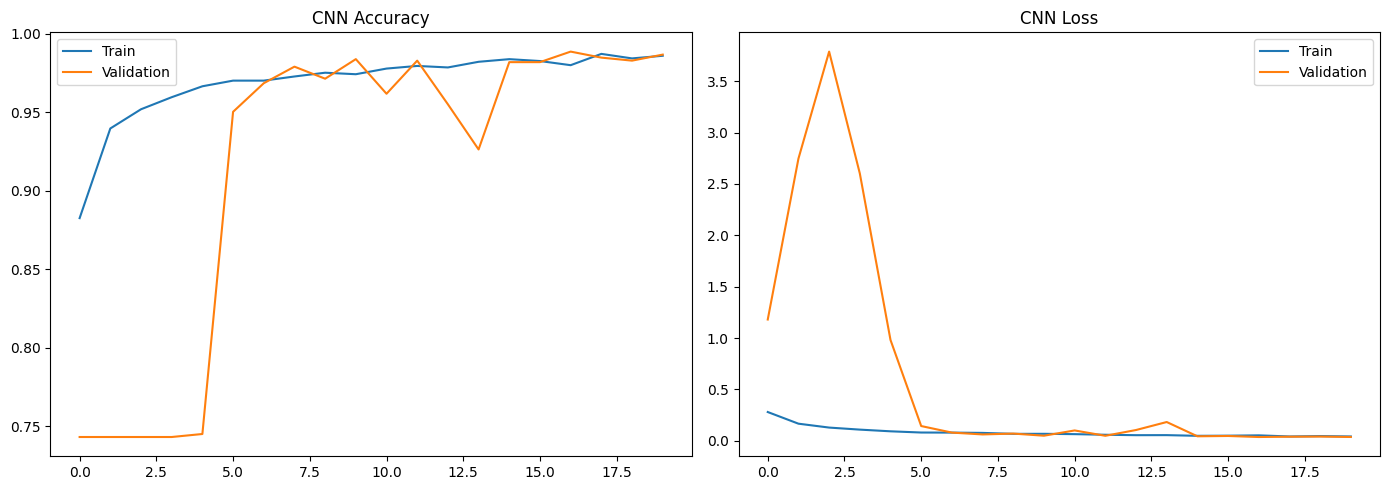

In [49]:
plot_history(
    cnn_history,
    "CNN"
)

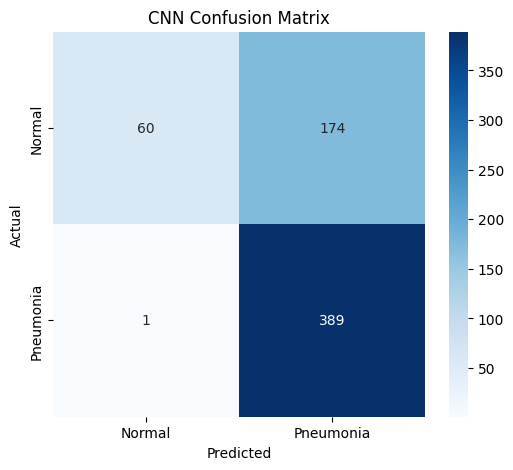

              precision    recall  f1-score   support

           0       0.98      0.26      0.41       234
           1       0.69      1.00      0.82       390

    accuracy                           0.72       624
   macro avg       0.84      0.63      0.61       624
weighted avg       0.80      0.72      0.66       624



In [50]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal","Pneumonia"],
    yticklabels=["Normal","Pneumonia"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")

plt.show()

print(classification_report(y_true, y_pred))

# MobileNetV2 - Feature Extraction

A pretrained MobileNetV2 model is used as a fixed feature extractor by freezing the convolutional backbone and training only the classification head.

In [51]:
mobilenet_model = build_model("MobileNetV2")

mobilenet_model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ sequential_1 (Sequential)     │ (None, 224, 224, 3)       │               0 │ input_layer_7[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ true_divide_3 (TrueDivide)    │ (None, 224, 224, 3)       │               0 │ sequential_1[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ subtract_1 (Subtract)         │ (None, 224, 224, 3)       │               0 │ true_divide_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ subtract_1[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 2,984,769 (11.39 MB)

 Trainable params: 724,225 (2.76 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [52]:
mobilenet_history = train_model(
    mobilenet_model,
    "MobileNetV2"
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 706ms/step - accuracy: 0.7925 - auc: 0.7734 - loss: 0.4786 - precision: 0.8323 - recall: 0.9092
Epoch 1: val_accuracy improved from None to 0.95402, saving model to ../models/MobileNetV2.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 126s 897ms/step - accuracy: 0.8452 - auc: 0.8925 - loss: 0.3494 - precision: 0.8754 - recall: 0.9229 - val_accuracy: 0.9540 - val_auc: 0.9847 - val_loss: 0.1725 - val_precision: 0.9561 - val_recall: 0.9832 - learning_rate: 1.0000e-04
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 716ms/step - accuracy: 0.9081 - auc: 0.9581 - loss: 0.2263 - precision: 0.9430 - recall: 0.9332
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.

Epoch 2: val_accuracy did not improve from 0.95402
131/131 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.9175 - auc: 0.9643 - loss: 0.2070 - precision: 0.9428 - recall: 0.9464 - val_accuracy: 0.9502 - val_auc: 0.9860 - val_loss: 0.1288 - val_precision: 0.9641 - val_recall: 0.9691 -

In [53]:
mobilenet_metrics, y_true, y_pred, y_prob = evaluate_model(
    mobilenet_model,
    test_dataset
)

pd.DataFrame(
    mobilenet_metrics,
    index=["MobileNetV2"]
).T

,MobileNetV2
Accuracy,0.770833
Precision,0.733459
Recall,0.994872
F1 Score,0.844396
AUC,0.938462


# Transfer Learning Benchmark

Multiple pretrained architectures are trained and evaluated using a common pipeline to enable a fair performance comparison.

In [54]:
results = []

trained_models = {}

histories = {}

In [55]:
def benchmark_model(model_name):

    model = build_model(model_name)

    history = train_model(model, model_name)

    metrics, y_true, y_pred, y_prob = evaluate_model(
        model,
        test_dataset
    )

    metrics["Model"] = model_name

    trained_models[model_name] = model

    histories[model_name] = history

    results.append(metrics)

    return model

In [56]:
for model_name in [
    "MobileNetV2",
    "DenseNet121",
    "EfficientNetB0"
]:

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    benchmark_model(model_name)

MobileNetV2
Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 985ms/step - accuracy: 0.7820 - auc: 0.8145 - loss: 0.4532 - precision: 0.8526 - recall: 0.8494
Epoch 1: val_accuracy improved from None to 0.91379, saving model to ../models/MobileNetV2.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - accuracy: 0.8559 - auc: 0.9071 - loss: 0.3318 - precision: 0.8975 - recall: 0.9100 - val_accuracy: 0.9138 - val_auc: 0.9822 - val_loss: 0.2074 - val_precision: 0.9007 - val_recall: 0.9936 - learning_rate: 1.0000e-04
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 697ms/step - accuracy: 0.9051 - auc: 0.9601 - loss: 0.2259 - precision: 0.9261 - recall: 0.9459
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.

Epoch 2: val_accuracy improved from 0.91379 to 0.95211, saving model to ../models/MobileNetV2.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.9128 - auc: 0.9635 - loss: 0.2126 - precision: 0.9359 - recall: 0.9474 - val_accuracy: 0.9521 - val_auc: 0.9864 - val_l

# Model Performance Comparison

The performance of all transfer learning models is compared using multiple evaluation metrics to identify the best-performing architecture.

In [57]:
results_df = (
    pd.DataFrame(results)
    .set_index("Model")
    .sort_values("Accuracy", ascending=False)
)

display(results_df.round(4))

,Accuracy,Precision,Recall,F1 Score,AUC
Model,,,,,
DenseNet121,0.8189,0.7856,0.9769,0.8709,0.9430
EfficientNetB0,0.7212,0.6949,0.9872,0.8157,0.9129
MobileNetV2,0.6939,0.6713,1.0000,0.8033,0.9313


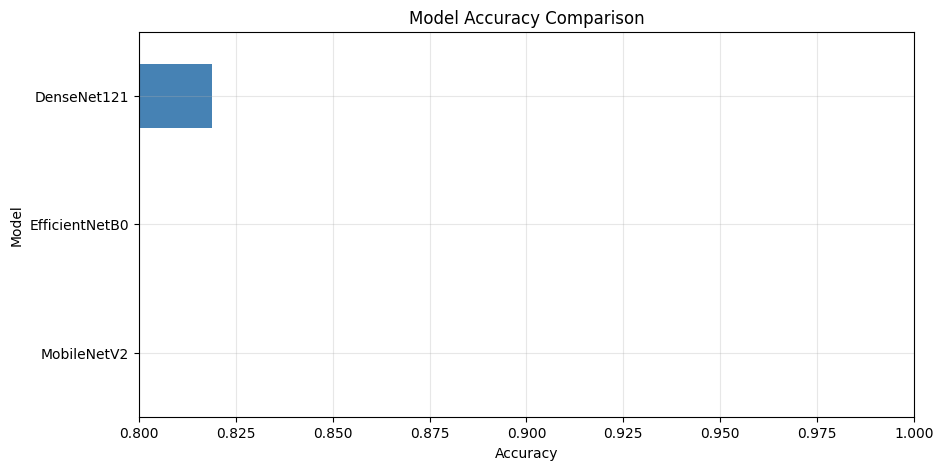

In [58]:
plt.figure(figsize=(10,5))

results_df["Accuracy"].sort_values().plot(
    kind="barh",
    color="steelblue"
)

plt.xlim(0.8, 1.0)

plt.xlabel("Accuracy")

plt.title("Model Accuracy Comparison")

plt.grid(alpha=0.3)

plt.show()

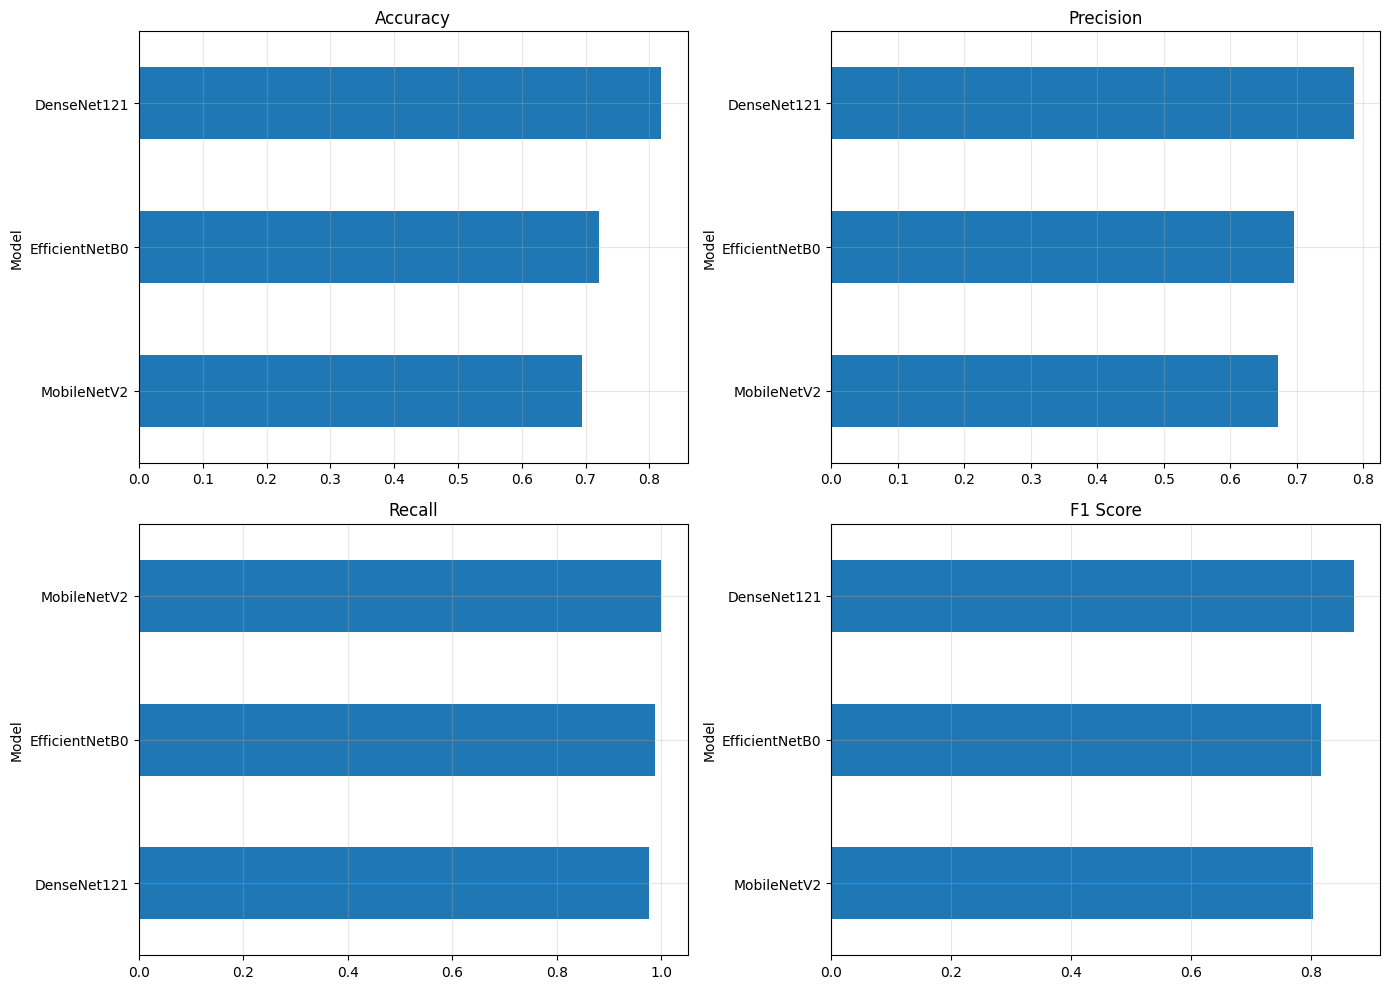

Best Model : DenseNet121


In [59]:
fig, axes = plt.subplots(2,2, figsize=(14,10))

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

for ax, metric in zip(axes.flatten(), metrics):

    results_df[metric].sort_values().plot(
        kind="barh",
        ax=ax
    )

    ax.set_title(metric)

    ax.grid(alpha=0.3)

plt.tight_layout()

plt.show()

best_model_name = results_df.index[0]

print(f"Best Model : {best_model_name}")

# Fine Tuning

The best-performing model is fine-tuned by unfreezing the final convolutional layers and continuing training with a lower learning rate.

In [60]:
best_model = trained_models["DenseNet121"]

base_model = None

for layer in best_model.layers:
    if isinstance(layer, tf.keras.Model):
        base_model = layer
        break

print(base_model.name)

sequential_1
